<a href="https://colab.research.google.com/github/DinRazar/neural_networks/blob/main/%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №6. Проектирование автоэнкодеров для решения прикладных задач**


## **Задание №1. Реализуйте автоэнкодер для колоризации чёрно-белых изображений**



* **Чем больше объектов разных классов будет в исходном датасете, тем универсальнее будет работа обученной Вами модели**

> Например, если в Вашем датасете только кошки, то все объекты кроме кошек будут колоризоваться некорректно. Соответственно следует очень тщательно подойти к выбору датасета.

  * Для решения данной задачи может подойти датасет [CIFAR-100](https://www.kaggle.com/datasets/fedesoriano/cifar100), но его минус заключается в том, что разрешение изображений довольно низкое

* Хорошим вариантом будет использование датасета [ImageNet](https://paperswithcode.com/dataset/imagenet), но ввиду его объёмности, процесс обучения займет большое количество времени, поэтому Вы можете использовать одну из его [сокращенных версий](https://www.kaggle.com/datasets/ifigotin/imagenetmini-1000)



 **Конечный выбор датасета осуществляется по Вашему желанию (хорошо, если это будут Ваши датасеты), учитывая рекомендации приведенные выше.**


**1.1. Загрузка и подготовка данных**

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Обучающая выборка: (50000, 32, 32, 3)
Тестовая выборка: (10000, 32, 32, 3)


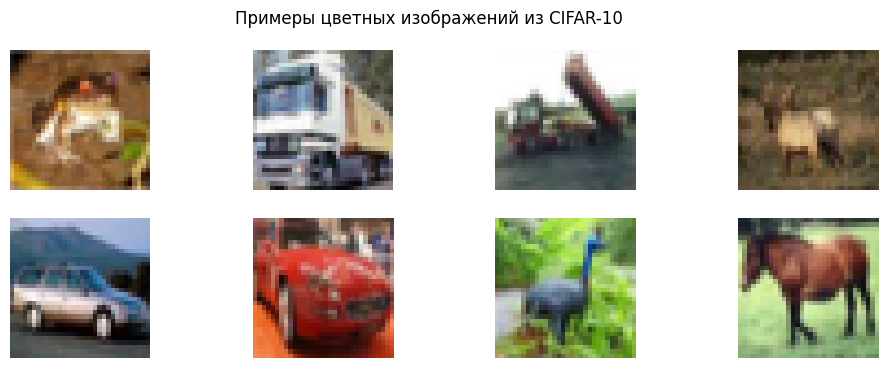

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
import tensorflow_datasets as tfds

# Загружаем CIFAR-10
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Нормализуем значения пикселей [0, 255] -> [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

# Покажем несколько примеров
plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(X_train[i])
    plt.axis('off')
plt.suptitle('Примеры цветных изображений из CIFAR-10')
plt.show()

**1.2. Преобразование RGB в оттенки серого**

Черно-белые изображения (вход): (50000, 32, 32, 1)
Цветные изображения (выход): (50000, 32, 32, 3)


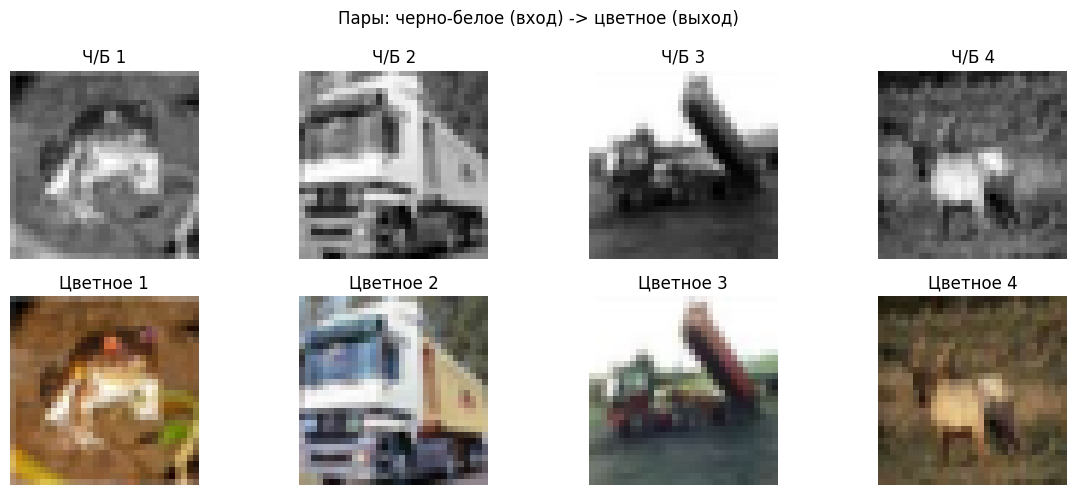

In [ ]:
def rgb_to_grayscale(images):
    # Формула: Y = 0.299*R + 0.587*G + 0.114*B
    grayscale = 0.299 * images[:,:,:,0] + 0.587 * images[:,:,:,1] + 0.114 * images[:,:,:,2]
    # Добавляем размерность канала
    grayscale = np.expand_dims(grayscale, axis=-1)
    return grayscale

# Создаем черно-белые изображения (вход для автоэнкодера)
X_train_gray = rgb_to_grayscale(X_train)
X_test_gray = rgb_to_grayscale(X_test)

print(f"Черно-белые изображения (вход): {X_train_gray.shape}")
print(f"Цветные изображения (выход): {X_train.shape}")

# Визуализируем пары
plt.figure(figsize=(12, 5))
for i in range(4):
    # Черно-белое
    plt.subplot(2, 4, i+1)
    plt.imshow(X_train_gray[i].squeeze(), cmap='gray')
    plt.title(f'Ч/Б {i+1}')
    plt.axis('off')

    # Цветное
    plt.subplot(2, 4, i+5)
    plt.imshow(X_train[i])
    plt.title(f'Цветное {i+1}')
    plt.axis('off')
plt.suptitle('Пары: черно-белое (вход) -> цветное (выход)')
plt.tight_layout()
plt.show()

**1.3. Архитектура автоэнкодера**

In [ ]:
def build_colorization_autoencoder(input_shape=(32, 32, 1)):
    # Энкодер
    encoder_input = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Декодер
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    decoder_output = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    model = Model(encoder_input, decoder_output)
    return model

# Создаем модель
autoencoder = build_colorization_autoencoder()
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,379 (1.27 MB)

 Trainable params: 333,379 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

**1.4. Компиляция и обучение**

In [ ]:
autoencoder.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error для сравнения цветов
    metrics=['mae']
)

# Уменьшаем выборку для ускорения обучения (берем 10000 изображений)
X_train_small = X_train[:10000]
X_train_gray_small = X_train_gray[:10000]

# Обучение
history_color = autoencoder.fit(
    X_train_gray_small, X_train_small,
    validation_split=0.2,
    epochs=20,
    batch_size=8,
    verbose=1
)

Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 0.0194 - mae: 0.1041 - val_loss: 0.0147 - val_mae: 0.0901
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0138 - mae: 0.0869 - val_loss: 0.0137 - val_mae: 0.0865
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0124 - mae: 0.0822 - val_loss: 0.0118 - val_mae: 0.0799
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0116 - mae: 0.0793 - val_loss: 0.0121 - val_mae: 0.0812
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0111 - mae: 0.0772 - val_loss: 0.0107 - val_mae: 0.0756
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0107 - mae: 0.0756 - val_loss: 0.0106 - val_mae: 0.0757
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0103 - mae: 0.0744 - val_loss: 0.0109 - val_mae: 0.0771
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0101 - mae: 0.0735 - val_loss: 0.0101 - val_mae: 0.0729
Epoch 9/20
1000/1000 ━━━━━━━━━━━━━━━━━━

**1.5. Визуализация результатов обучения**

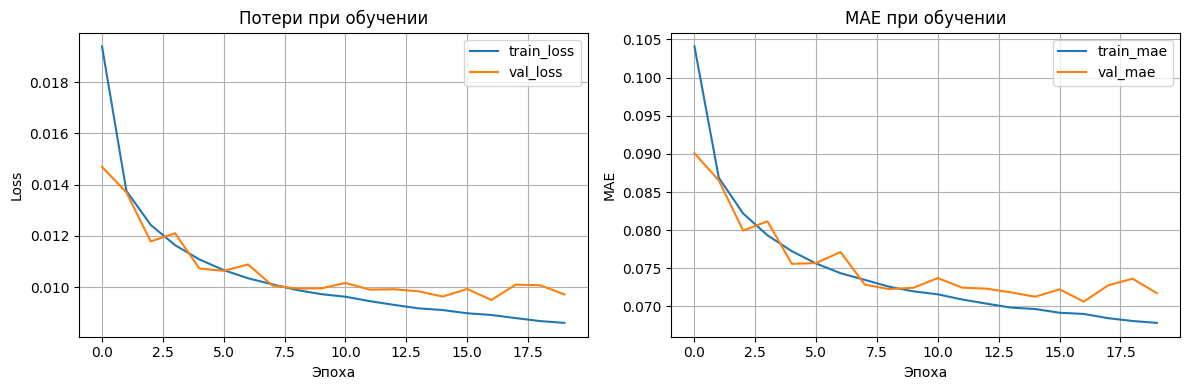

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_color.history['loss'], label='train_loss')
plt.plot(history_color.history['val_loss'], label='val_loss')
plt.title('Потери при обучении')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_color.history['mae'], label='train_mae')
plt.plot(history_color.history['val_mae'], label='val_mae')
plt.title('MAE при обучении')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**1.6. Тестирование модели на новых изображениях**

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


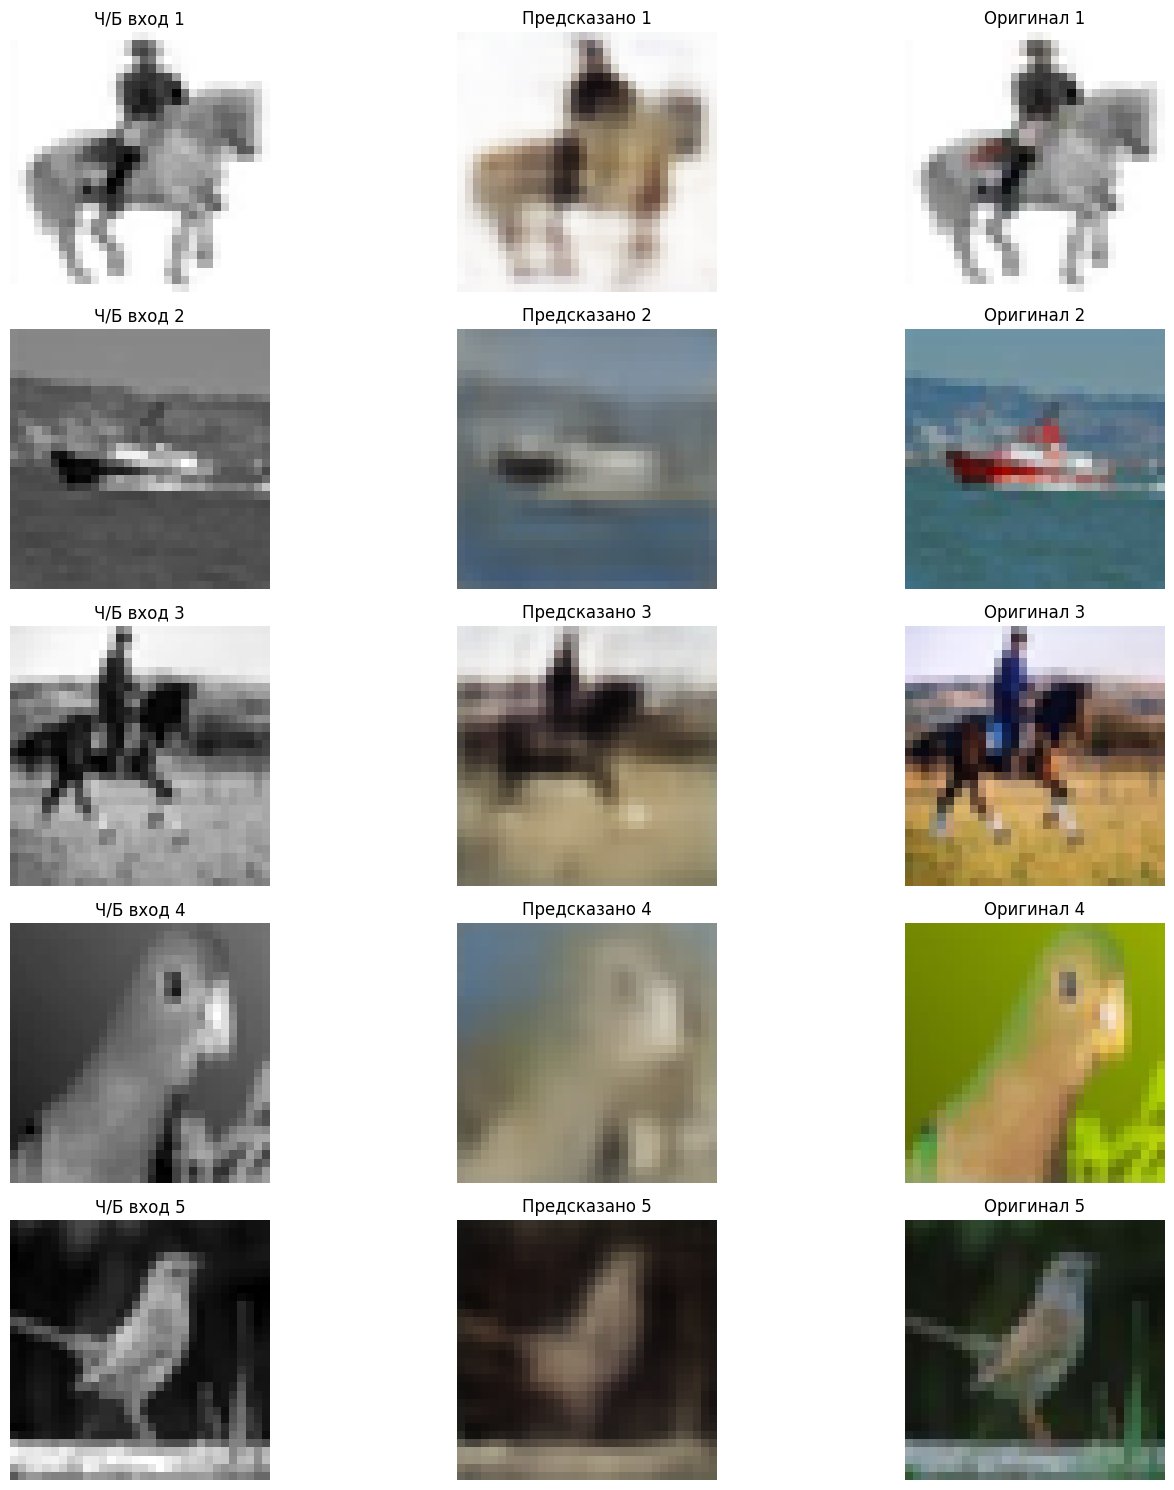

In [ ]:
# Берем несколько изображений из тестовой выборки
n_samples = 5
test_indices = np.random.choice(len(X_test), n_samples, replace=False)

# Предсказываем цвета
X_test_gray_sample = X_test_gray[test_indices]
pred_colors = autoencoder.predict(X_test_gray_sample)

# Визуализация
plt.figure(figsize=(15, n_samples * 3))
for i, idx in enumerate(test_indices):
    # Черно-белое (вход)
    plt.subplot(n_samples, 3, i*3 + 1)
    plt.imshow(X_test_gray[idx].squeeze(), cmap='gray')
    plt.title(f'Ч/Б вход {i+1}')
    plt.axis('off')

    # Предсказанное цветное
    plt.subplot(n_samples, 3, i*3 + 2)
    plt.imshow(pred_colors[i])
    plt.title(f'Предсказано {i+1}')
    plt.axis('off')

    # Оригинальное цветное
    plt.subplot(n_samples, 3, i*3 + 3)
    plt.imshow(X_test[idx])
    plt.title(f'Оригинал {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

## **Задание №2. Реализуйте автоэнкодер для удаления шума на однотипных изображениях**



1.  Подберите датасет, состоящий из однотипных изображений, которые в реальной жизни часто подвержены зашумлению, например спутниковые снимки, ночные фотографии и т.д.

2.  Затем примените к ним операцию зашумления и обучите модель. Также учитывайте тип шума, который Вы применяете. Он должен быть приближен к естественному.

Хороший пример реализации подобной задачи: https://www.kaggle.com/code/michalbrezk/denoise-images-using-autoencoders-tf-keras

**2.1. Загрузка датасета**

In [ ]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Нормализация
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"Обучающая: {X_train.shape}")
print(f"Тестовая: {X_test.shape}")

Обучающая: (50000, 32, 32, 3)
Тестовая: (10000, 32, 32, 3)


**2.2. Добавление шума к изображениям**

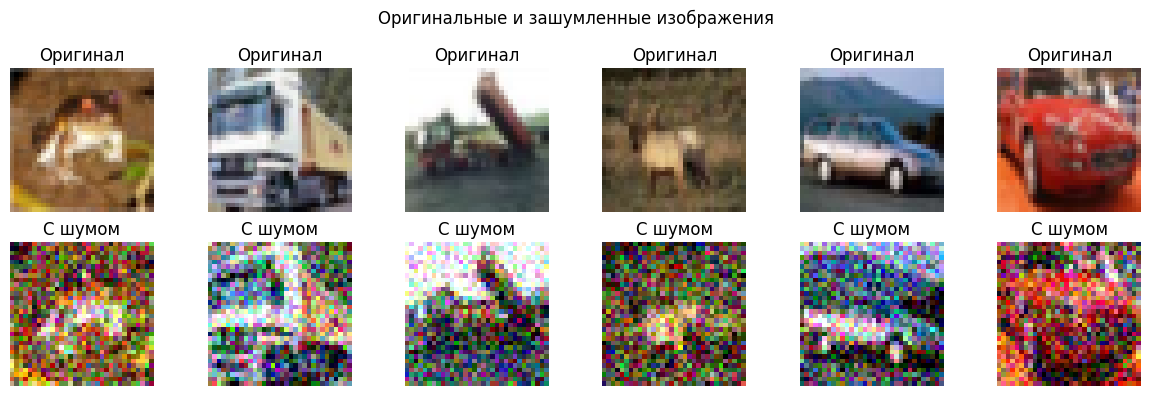

In [ ]:
def add_gaussian_noise(images, noise_factor=0.2):
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy, 0., 1.)

# Создаем зашумленные версии
X_train_noisy = add_gaussian_noise(X_train)
X_test_noisy = add_gaussian_noise(X_test)

# Визуализируем
plt.figure(figsize=(12, 4))
for i in range(6):
    # Оригинал
    plt.subplot(2, 6, i+1)
    plt.imshow(X_train[i])
    plt.title('Оригинал')
    plt.axis('off')

    # Зашумленный
    plt.subplot(2, 6, i+7)
    plt.imshow(X_train_noisy[i])
    plt.title('С шумом')
    plt.axis('off')
plt.suptitle('Оригинальные и зашумленные изображения')
plt.tight_layout()
plt.show()

**2.3. Создание архитектуры автоэнкодера для удаления шума**

In [ ]:
def build_denoising_autoencoder(input_shape=(32, 32, 3)):
    # Энкодер
    input_img = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)

    # Декодер
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    model = Model(input_img, decoded)
    return model

denoiser = build_denoising_autoencoder()
denoiser.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

**2.4. Компиляция и обучение**

In [ ]:
denoiser.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Берем часть данных для ускорения
X_train_small = X_train[:10000]
X_train_noisy_small = X_train_noisy[:10000]

# Обучение
history_denoise = denoiser.fit(
    X_train_noisy_small, X_train_small,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    verbose=1
)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 0.0188 - mae: 0.1012 - val_loss: 0.0098 - val_mae: 0.0744
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0089 - mae: 0.0702 - val_loss: 0.0085 - val_mae: 0.0687
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0077 - mae: 0.0654 - val_loss: 0.0071 - val_mae: 0.0626
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0071 - mae: 0.0629 - val_loss: 0.0068 - val_mae: 0.0609
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0067 - mae: 0.0610 - val_loss: 0.0069 - val_mae: 0.0619
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0064 - mae: 0.0594 - val_loss: 0.0068 - val_mae: 0.0618
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0063 - mae: 0.0589 - val_loss: 0.0061 - val_mae: 0.0578
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0060 - mae: 0.0575 - val_loss: 0.0059 - val_mae: 0.0565
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/

**2.5. Визуализация результатов**

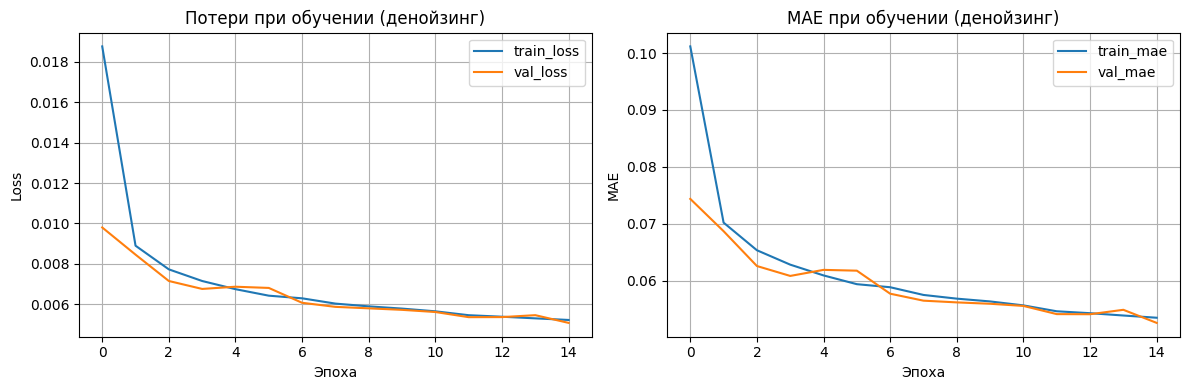

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 729ms/step


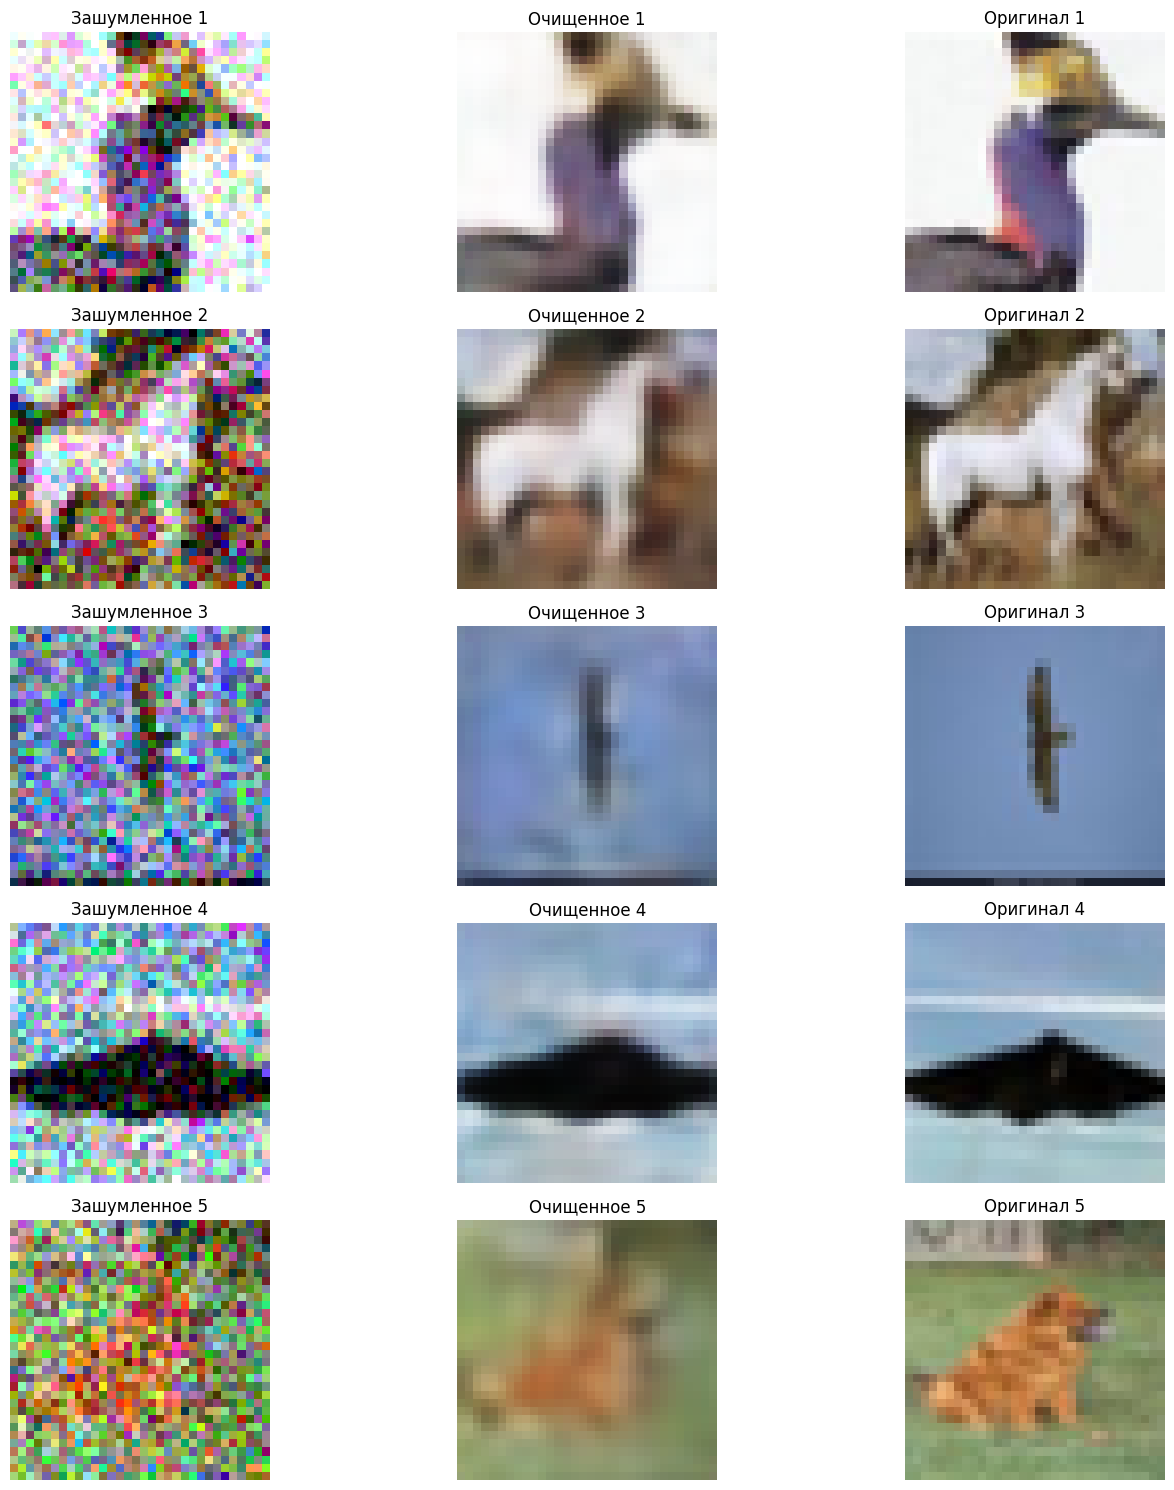

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_denoise.history['loss'], label='train_loss')
plt.plot(history_denoise.history['val_loss'], label='val_loss')
plt.title('Потери при обучении (денойзинг)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_denoise.history['mae'], label='train_mae')
plt.plot(history_denoise.history['val_mae'], label='val_mae')
plt.title('MAE при обучении (денойзинг)')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Тестирование
n_samples = 5
test_indices = np.random.choice(len(X_test), n_samples, replace=False)

# Предсказания
X_test_noisy_sample = X_test_noisy[test_indices]
denoised = denoiser.predict(X_test_noisy_sample)

# Визуализация
plt.figure(figsize=(15, n_samples * 3))
for i, idx in enumerate(test_indices):
    # Зашумленное
    plt.subplot(n_samples, 3, i*3 + 1)
    plt.imshow(X_test_noisy[idx])
    plt.title(f'Зашумленное {i+1}')
    plt.axis('off')

    # Очищенное (предсказание)
    plt.subplot(n_samples, 3, i*3 + 2)
    plt.imshow(denoised[i])
    plt.title(f'Очищенное {i+1}')
    plt.axis('off')

    # Оригинал
    plt.subplot(n_samples, 3, i*3 + 3)
    plt.imshow(X_test[idx])
    plt.title(f'Оригинал {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

## **Задание №.3 Реализуйте автоэнкодер для улучшения качества изображения путём увеличения его разрешения (апскейлинг-[определение](https://dic.academic.ru/dic.nsf/ruwiki/346555))**



1. На входной слой нейронной сети подаётся изображение с размерностью (256, 256,3) - X_test. В результате работы нейронной сети на выходном слое должно получиться изображение (512, 512, 3) - Y_test. В итоге мы получаем двукратный апскейл исходного изображения.

2. Датасет собираете из изображений, разрешение которых выше эталонного (512,512,3). Затем преобразуете их в указанные размерности и формируете из них обучающую и проверочную выборку.

3. Обучите модель. Отобразите графики обучения

4. Подумайте, каким образом можно будет адаптировать модель вашей нейронной сети для двухратного апскейла изображения с любой размерностью, большей, чем (256,256,3), с полным или частичным сохранением его исходных пропорций. Например: подаём на вход изображение с разрешением (1920, 1080, 3) - получаем изображение с разрешением (3840, 2160, 3), т.е. с полным сохранением исходных пропорций или (1792, 1024, 3) с частичным сохранением исходных пропорций.

> Подсказка: Для этого можно реализовать алгоритм предварительной обработки исходного изображения, перед подачей его в нейронную сеть

**3.1. Установка всего нужного**

In [1]:
!pip install kagglehub opencv-python matplotlib tensorflow

**3.2. Скачивание датасета**

In [2]:
import kagglehub

path = kagglehub.dataset_download("rahmasleam/flowers-dataset")
print("Dataset path:", path)

100%|██████████| 219M/219M [00:01<00:00, 125MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/rahmasleam/flowers-dataset/versions/1


In [5]:
import cv2
import numpy as np
from glob import glob

IMG_SIZE = 128

def load_images(dataset_path, limit=3000):
    # ищем ВСЕ картинки внутри классов
    image_paths = glob(dataset_path + "/*/*.jpg")
    image_paths += glob(dataset_path + "/*/*.png")

    print("Found images:", len(image_paths))

    images = []

    for file in image_paths[:limit]:
        img = cv2.imread(file)
        if img is None:
            continue

        # 💥 фикс: BGR → RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 💥 ВСЕ картинки → 128x128
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        images.append(img)

    return np.array(images)

base_path = "/root/.cache/kagglehub/datasets/rahmasleam/flowers-dataset/versions/1/flower_photos"

X = load_images(base_path, limit=3000)
print("Final shape:", X.shape)

Found images: 3670
Final shape: (3000, 128, 128, 3)


In [6]:
def degrade_and_upscale(images):
    result = []

    for img in images:
        small = cv2.resize(img, (64, 64), interpolation=cv2.INTER_AREA)
        restored = cv2.resize(small, (128, 128), interpolation=cv2.INTER_CUBIC)
        result.append(restored)

    return np.array(result)

X_low = degrade_and_upscale(X)

**3.3. Структура автоэнкодера**

In [7]:
from tensorflow.keras import layers, models

def build_autoencoder():
    input_img = layers.Input(shape=(128, 128, 3))

    x = layers.Conv2D(64, 3, activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)

    x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)

    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)

    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)

    output = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(x)

    model = models.Model(input_img, output)
    model.compile(optimizer='adam', loss='mse')

    return model

model = build_autoencoder()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331,459 (5.08 MB)

 Trainable params: 1,331,459 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

**3.4. Обучение**

In [8]:
model.fit(
    X_low, X,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 58s 401ms/step - loss: 0.0276 - val_loss: 0.0107
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 145ms/step - loss: 0.0089 - val_loss: 0.0082
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 147ms/step - loss: 0.0071 - val_loss: 0.0069
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 150ms/step - loss: 0.0064 - val_loss: 0.0063
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 155ms/step - loss: 0.0061 - val_loss: 0.0056
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 162ms/step - loss: 0.0056 - val_loss: 0.0053
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step - loss: 0.0054 - val_loss: 0.0051
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 15s 175ms/step - loss: 0.0052 - val_loss: 0.0050
Epoch 9/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 168ms/step - loss: 0.0050 - val_loss: 0.0047
Epoch 10/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 163ms/step - loss: 0.0049 - val_loss: 0.0046


In [9]:
model.save("super_resolution_model.h5")

In [10]:
from google.colab import files
files.download("super_resolution_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**3.5.Что-то**

In [11]:
decoded_imgs = model.predict(X_low)

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step


**3.6. Тестирование**

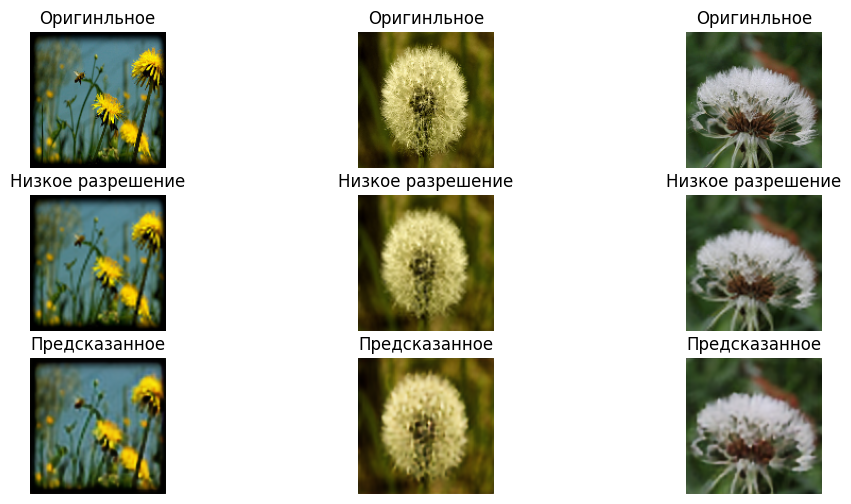

In [15]:
import matplotlib.pyplot as plt

n = 3
plt.figure(figsize=(12, 6))

for i in range(n):
    plt.subplot(3, n, i + 1)
    plt.imshow(X[i])
    plt.title("Оригинльное")
    plt.axis("off")

    plt.subplot(3, n, i + 1 + n)
    plt.imshow(X_low[i])
    plt.title("Низкое разрешение")
    plt.axis("off")

    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i])
    plt.title("Предсказанное")
    plt.axis("off")

plt.show()

**3.6. Адаптация для произвольных размеров**




In [16]:
import cv2
import numpy as np

def adapt_image(img, downscale=2, target_multiple=64):
    """
    Универсальная адаптация изображения:
    - работает с любым размером
    - приводит к кратному target_multiple
    - делает деградацию и восстановление

    Args:
        img: numpy array (H, W, 3)
        downscale: во сколько раз уменьшать (2 = 128→64)
        target_multiple: к чему приводить размер (64 или 128)

    Returns:
        restored_img: восстановленное изображение
    """

    h, w = img.shape[:2]

    # Сохраняем оригинальный размер
    orig_h, orig_w = h, w

    # Делаем размеры кратными target_multiple
    new_h = (h // target_multiple) * target_multiple
    new_w = (w // target_multiple) * target_multiple

    img_resized = cv2.resize(img, (new_w, new_h))

    # Деградация
    small = cv2.resize(
        img_resized,
        (new_w // downscale, new_h // downscale),
        interpolation=cv2.INTER_AREA
    )

    # Апскейл обратно
    restored = cv2.resize(
        small,
        (new_w, new_h),
        interpolation=cv2.INTER_CUBIC
    )

    # Возвращаем к исходному размеру
    final = cv2.resize(restored, (orig_w, orig_h))

    return final

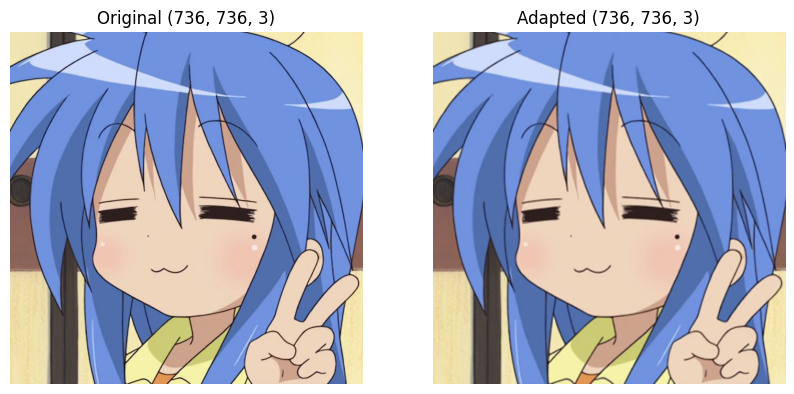

In [18]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/test.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

result = adapt_image(img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title(f"Original {img.shape}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result)
plt.title(f"Adapted {result.shape}")
plt.axis("off")

plt.show()

In [19]:
print("Original:", img.shape)
print("Result:", result.shape)

Original: (736, 736, 3)
Result: (736, 736, 3)
